In [15]:
import numpy as np
import cv2
img = cv2.imread(r'C:\Users\safit\OneDrive\GitHub\3D-US-reconstraction-for-detecting-facial-fracture\Dataset\Patient1\IMG_frames\image_152993002660.png', cv2.IMREAD_GRAYSCALE)
brightness_threshold = 75  # Example threshold value
# Load the ultrasound image in grayscale
# Assume 'img' is the loaded ultrasound grayscale image
bone_mask = np.zeros_like(img)

# Threshold the image to isolate the bright line (bone)
_, thresholded = cv2.threshold(img, brightness_threshold, 255, cv2.THRESH_BINARY)

# Morphological operations to clean up:
bone_mask = cv2.morphologyEx(thresholded, cv2.MORPH_OPEN, np.ones((3,3),np.uint8))

# Overlay the mask on the original image for visualization
overlay = cv2.addWeighted(img, 0.7, bone_mask, 0.3, 0)

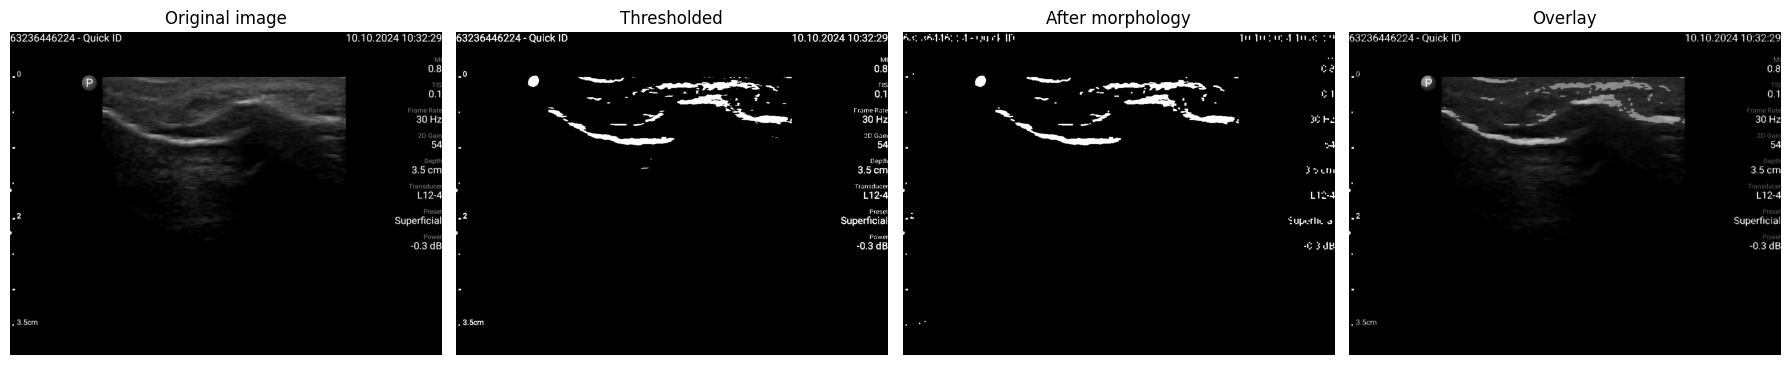

In [16]:
import matplotlib.pyplot as plt

if img is None:
    raise FileNotFoundError("Could not load image: set the correct path first")

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
axes[0].imshow(img, cmap='gray')
axes[0].set_title('Original image')
axes[1].imshow(thresholded, cmap='gray')
axes[1].set_title('Thresholded')
axes[2].imshow(bone_mask, cmap='gray')
axes[2].set_title('After morphology')
axes[3].imshow(overlay, cmap='gray')
axes[3].set_title('Overlay')
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()
